# Flu Shot Learning: H1N1 and Seasonal Vaccine Probabilities

This notebook trains two probability models for the DrivenData Flu Shot Learning competition. It uses CatBoost because it can learn from mixed numeric/categorical survey data while handling missing values without fragile manual ordinal encoding.

**Metric:** the mean ROC AUC of `h1n1_vaccine` and `seasonal_vaccine`. The final output contains probabilities, not hard class labels.

The code works both on Kaggle and from this repository. On Kaggle, set `DATA_DIR` to the directory containing the competition CSV files if automatic discovery does not find it.


In [1]:
from pathlib import Path
import importlib.util
import sys

# The Kaggle image normally includes CatBoost. Install it only when needed.
if importlib.util.find_spec("catboost") is None:
    !{sys.executable} -m pip install -q catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


## 1. Locate and load the data


In [2]:
def find_data_dir():
    candidates = [
        Path("/kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset"),
        Path("/kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset"),
        Path("/kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset"),
        
    ]
    for candidate in candidates:
        if (candidate / "training_set_features.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find training_set_features.csv. Set DATA_DIR to the folder containing the competition CSV files."
    )

DATA_DIR = find_data_dir()
print(f"Using data directory: {DATA_DIR.resolve()}")

train_features = pd.read_csv(DATA_DIR / "training_set_features.csv")
train_labels = pd.read_csv(DATA_DIR / "training_set_labels.csv")
test_features = pd.read_csv(DATA_DIR / "test_set_features.csv")

assert train_features["respondent_id"].is_unique
assert test_features["respondent_id"].is_unique
assert set(train_features["respondent_id"]) & set(test_features["respondent_id"]) == set()
assert train_features["respondent_id"].equals(train_labels["respondent_id"])

TARGETS = ["h1n1_vaccine", "seasonal_vaccine"]
print(f"Train shape: {train_features.shape}; test shape: {test_features.shape}")
display(train_features.head(3))
display(train_labels[TARGETS].mean().rename("positive_rate").to_frame())


Using data directory: /kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset
Train shape: (26707, 36); test shape: (26708, 36)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo


,positive_rate
h1n1_vaccine,0.212454
seasonal_vaccine,0.465608


## 2. Inspect missingness and target balance

Missing survey answers are informative in this dataset, so they are retained as explicit categorical values rather than dropped.


,missing_fraction
employment_occupation,0.504362
employment_industry,0.499120
health_insurance,0.459580
income_poverty,0.165612
doctor_recc_seasonal,0.080878
doctor_recc_h1n1,0.080878
rent_or_own,0.076459
employment_status,0.054780
marital_status,0.052720
education,0.052683


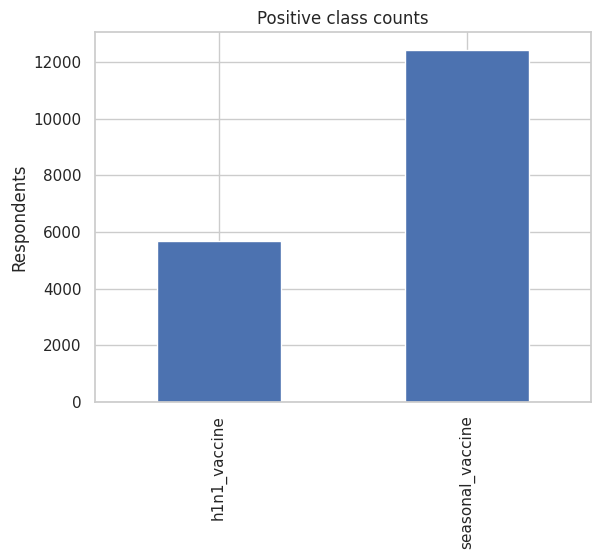

In [3]:
missing = (
    train_features.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)
display(missing.head(15))

target_counts = train_labels[TARGETS].sum().rename("vaccinated")
target_counts.plot(kind="bar", title="Positive class counts")
plt.ylabel("Respondents")
plt.show()


## 3. Prepare CatBoost features

The respondent ID is an identifier, not a meaningful predictive feature, so it is excluded. All remaining object columns are treated as categorical. Numeric columns are left numeric. CatBoost receives missing categorical values as the explicit token `__MISSING__`.


In [4]:
X = train_features.drop(columns=["respondent_id"]).copy()
X_test = test_features.drop(columns=["respondent_id"]).copy()

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
for column in categorical_columns:
    X[column] = X[column].fillna("__MISSING__").astype(str)
    X_test[column] = X_test[column].fillna("__MISSING__").astype(str)

cat_feature_indices = [X.columns.get_loc(column) for column in categorical_columns]
y = train_labels[TARGETS].copy()
print(f"Categorical columns: {len(categorical_columns)}")
print(f"Numeric columns: {X.shape[1] - len(categorical_columns)}")


Categorical columns: 12
Numeric columns: 23


## 4. Local validation

A single stratified holdout gives a quick, reproducible check before fitting on all rows. The two labels are correlated, so the stratification key combines the two binary targets and preserves the four observed label combinations.


In [5]:
stratify_key = y[TARGETS].astype(str).agg("_".join, axis=1)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=stratify_key
)

def make_model(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=1200,
        depth=7,
        learning_rate=0.045,
        loss_function="Logloss",
        eval_metric="AUC",
        l2_leaf_reg=5.0,
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )

validation_predictions = pd.DataFrame(index=y_valid.index)
validation_models = {}
for target in TARGETS:
    model = make_model()
    model.fit(
        X_train,
        y_train[target],
        cat_features=cat_feature_indices,
        eval_set=(X_valid, y_valid[target]),
        use_best_model=True,
        early_stopping_rounds=100,
    )
    validation_models[target] = model
    validation_predictions[target] = model.predict_proba(X_valid)[:, 1]
    print(f"{target}: best iteration = {model.get_best_iteration()}")

auc_by_target = {
    target: roc_auc_score(y_valid[target], validation_predictions[target])
    for target in TARGETS
}
print(pd.Series(auc_by_target).to_frame("validation_auc"))
print(f"Mean validation ROC AUC: {np.mean(list(auc_by_target.values())):.5f}")


h1n1_vaccine: best iteration = 567
seasonal_vaccine: best iteration = 491
                  validation_auc
h1n1_vaccine            0.878340
seasonal_vaccine        0.861264
Mean validation ROC AUC: 0.86980


## 5. Fit full-data models and predict the test set

After the validation check, each target is refit using all available labeled rows. The number of iterations is taken from the validation model and padded slightly to avoid underfitting after adding the validation rows.


In [6]:
test_predictions = {}
for target in TARGETS:
    best_iteration = validation_models[target].get_best_iteration()
    final_iterations = max(100, int(best_iteration + 1.10 * 100))
    final_model = make_model(seed=RANDOM_STATE)
    final_model.set_params(iterations=final_iterations)
    final_model.fit(
        X,
        y[target],
        cat_features=cat_feature_indices,
        verbose=False,
    )
    test_predictions[target] = final_model.predict_proba(X_test)[:, 1]
    print(f"{target}: fitted for {final_iterations} iterations")


h1n1_vaccine: fitted for 677 iterations
seasonal_vaccine: fitted for 601 iterations


## 6. Create and verify the submission

The competition expects exactly three columns and floating-point probabilities in the range `[0, 1]`.


In [7]:
submission = pd.DataFrame({
    "respondent_id": test_features["respondent_id"],
    "h1n1_vaccine": np.clip(test_predictions["h1n1_vaccine"], 0.0, 1.0),
    "seasonal_vaccine": np.clip(test_predictions["seasonal_vaccine"], 0.0, 1.0),
})

assert list(submission.columns) == ["respondent_id", "h1n1_vaccine", "seasonal_vaccine"]
assert len(submission) == len(test_features)
assert submission["respondent_id"].equals(test_features["respondent_id"])
assert submission[TARGETS].notna().all().all()
assert ((submission[TARGETS] >= 0) & (submission[TARGETS] <= 1)).all().all()

output_path = Path("submission.csv")
submission.to_csv(output_path, index=False)
print(f"Saved {len(submission):,} predictions to {output_path.resolve()}")
display(submission.head())
display(submission[TARGETS].describe().loc[["min", "mean", "max"]])


Saved 26,708 predictions to /kaggle/working/submission.csv


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,26707,0.123589,0.171270
1,26708,0.023921,0.025307
2,26709,0.213314,0.701491
3,26710,0.634106,0.887424
4,26711,0.334248,0.548872


,h1n1_vaccine,seasonal_vaccine
min,0.001987,0.005940
mean,0.210182,0.464788
max,0.991358,0.992245


Upload `submission.csv` to the competition submission page. For experiments, change one modeling choice at a time and compare the local mean ROC AUC; do not optimize a single target while ignoring the macro average.
